In [28]:
# Imports
import os
import sys
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import pyreadstat
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
from typing import List
from sklearn.metrics import mean_squared_error, r2_score, log_loss
from stargazer.stargazer import Stargazer
from IPython.display import display, Latex, HTML
from statsmodels.iolib.summary2 import summary_col
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore") 

In [29]:
## Data Imports
grav = pd.read_csv('https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-gravity.csv')
ind = pd.read_csv('https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-industryflows.csv')
pwt = pd.read_csv('https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-pwt.csv')

In [30]:
## Filter data
grav = grav.loc[grav['iso_o']=='POL']
ind = ind[ind['iso_o'] == 'POL']
pwt = pwt[pwt['countrycode'] == 'POL']

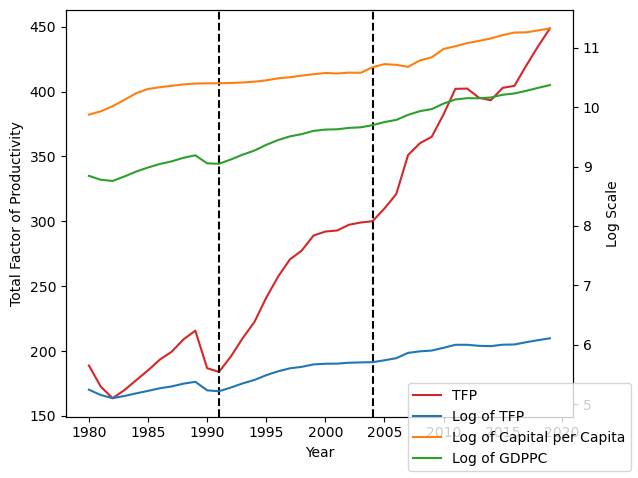

In [59]:
## Part 3
pwt['gdppc'] = pwt['rgdpo']/pwt['pop']
pwt['k'] = pwt['cn']/pwt['pop']
a = 0.3
pwt['A'] = pwt['gdppc'] / ((pwt['k'] ** a) * pwt['hc']**(1 - a))

pwt['lnA'] = np.log(pwt['A'])
pwt = pwt.loc[(pwt['year'] >= 1980) & (pwt['year'] <= 2019)]
fig, ax1 = plt.subplots()

ax1.plot(pwt['year'],pwt['A'],color='tab:red',label='TFP')

ax2 = ax1.twinx()

ax2.plot(pwt['year'],pwt['lnA'],label='Log of TFP')
ax2.plot(pwt['year'],np.log(pwt['k']),label='Log of Capital per Capita')
ax2.plot(pwt['year'],np.log(pwt['gdppc']),label='Log of GDPPC')

ax1.axvline(x=1991,linestyle='dashed',color='black')
ax1.axvline(x=2004,linestyle='dashed',color='black')

fig.legend(loc=4)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Factor of Productivity')
ax2.set_ylabel('Log Scale')
fig.tight_layout()

During this period, Poland experienced consistent economic growth that was driven by different factors. In the 1980s, Poland's TFP was relatively stagnant. However, productivity started increasing in 1991, coinciding with the collapse of the Soviet Union and the end of communist rule over Poland in 1989. During this period, growth appears to have been largely driven by this increase in productivity, whereas per capita capital investment in Poland remained largely stable. However, starting in 2004, when Poland joined the European Union, it began to experience a more notable increase in capital investment along with continuning productivity growth. During this period, Poland's productivity more than doubled. 

In [51]:
## Part 4a
ind2000 = ind.loc[ind['year']==2000]
ind2021 = ind.loc[ind['year']==2021]

xtot2000 = np.sum(ind2000['value'])
x_wdtot2000 = np.sum(ind2000['value_wd'])
ind2000['rca'] = (ind2000['value']/ind2000['value_wd']) / (xtot2000/x_wdtot2000)

xtot2021 = np.sum(ind2021['value'])
x_wdtot2021 = np.sum(ind2021['value_wd'])
ind2021['rca'] = (ind2021['value']/ind2021['value_wd']) / (xtot2021/x_wdtot2021)

rca_data = pd.merge(ind2000.loc[:,['hs2','rca']],ind2021.loc[:,['hs2','rca']],on=['hs2'],suffixes=['2000','2021'])
rca_data['delta'] = rca_data['rca2021']-rca_data['rca2000']


top2000 = rca_data.loc[:,['hs2','rca2000']].copy().sort_values(by='rca2000',ascending=False).reset_index(drop=True)
top2021 = rca_data.loc[:,['hs2','rca2021']].copy().sort_values(by='rca2021',ascending=False).reset_index(drop=True)

joined = pd.concat([top2000,top2021],axis=1)

joined.head(50)

,hs2,rca2000,hs2,rca2021
0,59,3.334205,48,2.249322
1,5,2.993502,83,2.122487
2,60,2.607487,89,2.107687
3,58,2.516605,5,2.023162
4,83,2.428152,62,2.014202
5,69,2.420498,23,1.967183
6,35,2.407170,18,1.962232
7,55,2.373837,1,1.929411
8,51,2.369527,56,1.928308
9,32,2.347396,86,1.900022


In [52]:
rca_data.copy().loc[:,['hs2','delta']].sort_values(by='delta',ascending=False).head(5)

,hs2,delta
61,62,1.764771
60,61,1.382432
0,1,1.372026
23,24,1.302534
93,95,1.248995


In [53]:
rca_data.copy().loc[:,['hs2','delta']].sort_values(by='delta',ascending=False).tail(5)

,hs2,delta
50,51,-1.379129
51,52,-1.419100
29,30,-1.435127
58,59,-1.676718
59,60,-1.783139


In [55]:
len(rca_data[rca_data['rca2021'] >= 1])

61

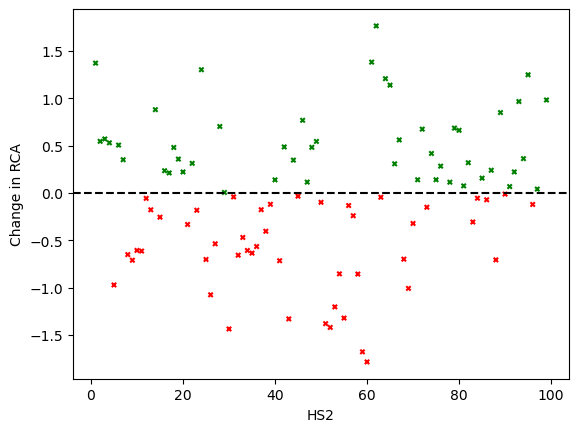

In [40]:
colors = ['r' if RCAdelta < 0 else 'g' for RCAdelta in rca_data['delta']]

plt.figure()
plt.scatter(rca_data['hs2'],rca_data['delta'],10,marker='x',c=colors)
plt.axhline(0,color='k',linestyle='--')
plt.xlabel("HS2")
plt.ylabel("Change in RCA")
plt.show()

In [45]:
## Part 4b
grav = grav.loc[grav['year']==2020]
grav['lnD']=np.log(grav['distw'])
grav['lnGDPd']=np.log(grav['gdp_d'])
grav['lnVal']=np.log(grav['value']+1)

x = grav.loc[:,['lnD','lnGDPd','comlang_ethno','contig','diplo_disagreement','comleg_posttrans','wto_d','eu_d','rta']]
x = sm.add_constant(x)
y = grav['lnVal']
model = sm.OLS(y,x,missing='drop')
res = model.fit(cov_type="HC1")

varNames = {'lnD':'Log(Distance)','lnGDPd':'Log(Destination GDP)','comlang_ethno':'Common Language','contig':'Shared Border','diplo_disagreement':'UN Diplomatic Disagreement Score','comleg_posttrans':'Common Legal System', 'wto_d':'WTO Member (D)','eu_d':'EU Member (D)','rta':'Regional Trade Agreement'}

stargazer = Stargazer([res])
stargazer.covariate_order(['lnD','lnGDPd','contig','comlang_ethno','comleg_posttrans','eu_d','rta','wto_d','diplo_disagreement','const'])
stargazer.rename_covariates(varNames)
stargazer.custom_columns(['Gravity Model'])
stargazer.dependent_variable_name('ln(Value)')
stargazer